In [ ]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
from scipy import stats
from sklearn.metrics import ndcg_score, root_mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [28]:
all_data = pd.read_csv('tables/zaModel.csv')
all_data = all_data.fillna(-1)

In [ ]:
# izbacuje se jer naivni bajas ocekuje da su fature-i nezavisi, 
# a lap_length i num_of_laps imaju jaku negativnu korelaciju
all_data = all_data.drop('lap_length', axis=1)

In [30]:
#da se izbace prazna mesta iz imena kolona
all_data.columns = all_data.columns.str.strip()

#kategorijske i numericke kolone
categorical_cols = ['constructor', 'driverId', 'race_name',
                                'circuit']

numerical_cols = ['season', 'round', 'position_quali', 'grid',
                  'number_of_laps', 'number_of_corners', 
                  'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 
                  'WindSpeed', 'rain_bin', 'wind_direction', 
                  'last_year_time', 'avg_position_last5', 
                  'num_dnfs_last5', 'avg_gained_lost_last5',
                  'avg_pos_last5', 'avg_pit_duration_last5',
                  'avg_pit_duration_prev_race','avg_pit_duration_prev_driver_race', 
                  'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']

#target kolona
target_col = 'position_race'

In [33]:
y = all_data['position_race']

In [ ]:
all_data = all_data.sort_values(by=["season", "round"]).reset_index(drop=True)

# uzima sve trke, bez ponavljanja
unique_races = all_data[["season", "round"]].drop_duplicates().reset_index(drop=True)
num_races = len(unique_races)

# velicina train i test seta
train_size = int(num_races * 0.7)
test_size = num_races - train_size

In [35]:
test_size

45

In [36]:
X = all_data[categorical_cols + numerical_cols].copy()
y = all_data[target_col] 


# Split
X_train = X[:train_size * 20]
X_test = X[train_size * 20:]
y_train = y[:train_size * 20]
y_test = y[train_size * 20:]

In [37]:
# Label encoding kategorijskih feature-a
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
oe.fit(X_train[categorical_cols])
X_test.loc[:, categorical_cols] = oe.transform(X_test[categorical_cols])
X_train.loc[:, categorical_cols] = oe.transform(X_train[categorical_cols])



In [ ]:
# Odvojeno treniranje za kategorijske i numericke feature
model_cat = MultinomialNB(alpha=100)
model_num = GaussianNB()

model_cat.fit(X_train[categorical_cols], y_train)
model_num.fit(X_train[numerical_cols], y_train)

# Kombinacija predikcija (log-probabilistički pristup)
log_prob_cat = model_cat.predict_log_proba(X_test[categorical_cols])
log_prob_num = model_num.predict_log_proba(X_test[numerical_cols])

# Sabiranje log-verovatnoća
combined_log_prob = log_prob_num + log_prob_cat 

In [ ]:
import numpy as np

num_drivers = 20
num_races = combined_log_prob.shape[0] // num_drivers

# Dodavanje race_ids: 0,0,...,0 (20 puta), 1,1,...,1 (20 puta), itd.
race_ids = np.repeat(np.arange(num_races), num_drivers)


# Ranks po trci
ranks_pred = np.zeros((num_races, num_drivers), dtype=int)

for i in range(num_races):
    # Biranje redova za trku i
    preds = combined_log_prob[i * num_drivers : (i + 1) * num_drivers]  # (20, 20)

    # Očekivana pozicija (weighted average)
    expected_pos = np.sum(np.exp(preds) * np.arange(1, 21), axis=1)  # (20,)

    # Rangiranje: manji expected_pos znači bolji plasman
    sorted_idx = expected_pos.argsort()
    driver_ranks = np.empty_like(sorted_idx)
    driver_ranks[sorted_idx] = np.arange(num_drivers)

    ranks_pred[i] = driver_ranks + 1


In [42]:
y_test = pd.DataFrame(y_test)


In [44]:
y_test = y_test.to_numpy()

In [45]:
y_test = y_test.reshape(45, 20)

In [ ]:
ndcg_values = []
tau_list = []
spearman_list = []
rmse_list = []

num_races = ranks_pred.shape[0] 

for i in range(num_races):
    # prave i predvidjene vrednosti
    true_scores = y_test[i]    
    pred_scores = ranks_pred[i]  

    # Pretvarajne u rangove
    true_ranks = pd.Series(-true_scores).rank(method='min').values
    pred_ranks = pd.Series(-pred_scores).rank(method='min').values

    # 2D niz za ndcg_score
    true_ranks_2d = true_ranks.reshape(1, -1)
    pred_ranks_2d = pred_ranks.reshape(1, -1)

    # NDCG@10
    ndcg = ndcg_score(true_ranks_2d, pred_ranks_2d, k=10)
    ndcg_values.append(ndcg)

    # Kendall's Tau & Spearman (za rangove)
    tau, _ = stats.kendalltau(true_ranks, pred_ranks)
    spearman, _ = stats.spearmanr(true_ranks, pred_ranks)
    tau_list.append(tau)
    spearman_list.append(spearman)

    # RMSE rangova
    rmse = root_mean_squared_error(true_ranks, pred_ranks) 
    rmse_list.append(rmse)

# Racunanje prosečnih vrednosti
avg_ndcg = np.mean(ndcg_values)
avg_tau = np.nanmean(tau_list)
avg_spearman = np.nanmean(spearman_list)
avg_rmse = np.mean(rmse_list)

print(f"Average NDCG@10: {avg_ndcg:.4f}")
print(f"Average Kendall's Tau: {avg_tau:.4f}")
print(f"Average Spearman: {avg_spearman:.4f}")
print(f"Average RMSE: {avg_rmse:.4f}")


Average NDCG@10: 0.6818
Average Kendall's Tau: 0.1329
Average Spearman: 0.1829
Average RMSE: 7.2450


In [ ]:
all_true_ranks = []
all_pred_ranks = []

for i in range(ranks_pred.shape[0]):
    true_scores = y_test[i]       
    pred_scores = ranks_pred[i]   

    true_rank = pd.Series(-true_scores.flatten()).rank(method='min').astype(int).values
    pred_rank = pd.Series(-pred_scores.flatten()).rank(method='min').astype(int).values

    all_true_ranks.append(true_rank)
    all_pred_ranks.append(pred_rank)

true_ranks = np.array(all_true_ranks) 
pred_ranks = np.array(all_pred_ranks)


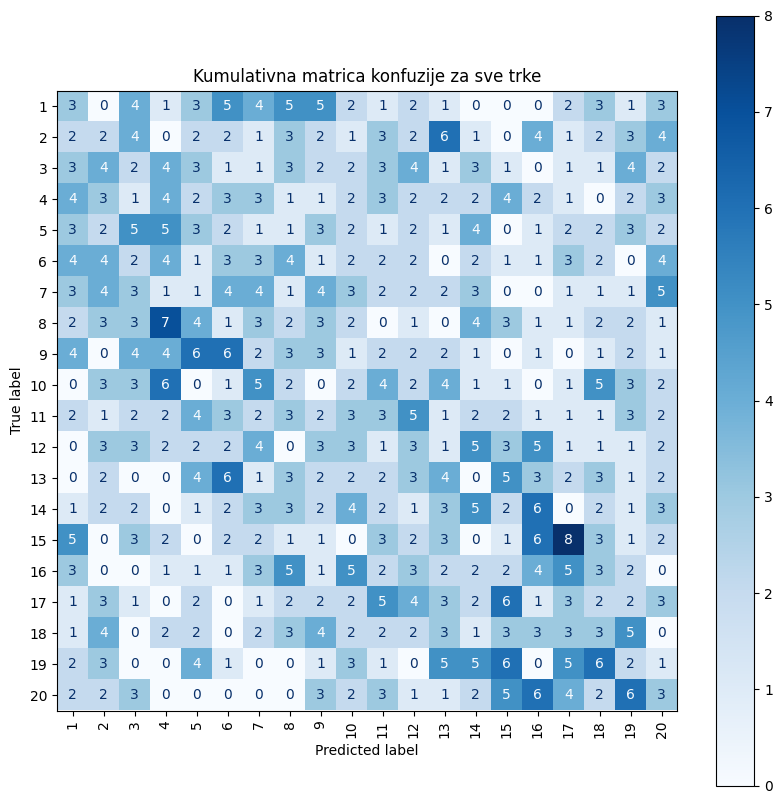

In [ ]:
# sve u jedan vektor
y_true = true_ranks.flatten()
y_pred = pred_ranks.flatten()

# Kreiranje konfuzione matrice
cm = confusion_matrix(y_true, y_pred, labels=np.arange(1, 21))

# Prikaz matrice
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(1, 21))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation='vertical')
plt.title("Kumulativna matrica konfuzije za sve trke")
plt.show()
